In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Constants
G = 4 * np.pi**2           # AU^3/yr^2/M_sun -- G=4pi^2 so Earth's period = 1 year at a = 1 AU
S0 = 1361                  # solar constant (W/m^2)

M_SUN = 1.0
M_EARTH = 3.003e-6         # in solar mass
M_JUPITER = 9.545e-4       # in solar mass

EARTH_R0 = 1.0             # AU
EARTH_V0 = 2 * np.pi       # AU/yr (circular orbital velocity)
EARTH_V0_ECCENTRIC = 2 * np.pi * 1.01

JUPITER_R0 = 5.2           # AU
JUPITER_V0 = 2 * np.pi / np.sqrt(JUPITER_R0)   # AU/yr

SOFTENING = 0.01           # AU (1% of Earth-Sun distance)

In [3]:
#Acceleration (2D)
def acceleration(positions, masses, softening=SOFTENING):
    N = len(masses)
    acc = np.zeros_like(positions)
    for i in range(N):
        for j in range(N):
            if i != j:
                r_vec = positions[j] - positions[i]
                r = np.linalg.norm(r_vec)
                r_soft = np.sqrt(r**2 + softening**2)
                acc[i] += G * masses[j] * r_vec / r_soft**3
    return acc

In [4]:
# Integrators
def rk4_step(positions, velocities, masses, dt):
    a1 = acceleration(positions, masses, G)
    k1_r = velocities
    k1_v = a1

    a2 = acceleration(positions + 0.5*dt*k1_r, masses, G)
    k2_r = velocities + 0.5*dt*k1_v
    k2_v = a2

    a3 = acceleration(positions + 0.5*dt*k2_r, masses, G)
    k3_r = velocities + 0.5*dt*k2_v
    k3_v = a3

    a4 = acceleration(positions + dt*k3_r, masses, G)
    k4_r = velocities + dt*k3_v
    k4_v = a4

    new_positions = positions + (dt/6)*(k1_r + 2*k2_r + 2*k3_r + k4_r)
    new_velocities = velocities + (dt/6)*(k1_v + 2*k2_v + 2*k3_v + k4_v)

    return new_positions, new_velocities

def leapfrog_step(positions, velocities, masses, dt):
    positions_new = positions + dt * velocities
    acc_new = acceleration(positions_new, masses)
    velocities_new = velocities + dt * acc_new

    return positions_new, velocities_new

In [5]:
# Energy and Angular Momentum
def total_energy(positions, velocities, masses):
    N = len(masses)
    kinetic = 0.5 * np.sum(masses * np.sum(velocities**2, axis=1))

    potential = 0
    for i in range(N):
        for j in range(i+1, N):
            r = np.linalg.norm(positions[i] - positions[j])
            potential -= G * masses[i] * masses[j] / r
    return kinetic + potential


def total_angular_momentum(positions, velocities, masses):
    L = 0
    for i in range(len(masses)):
        r = positions[i]
        v = velocities[i]
        L += masses[i] * (r[0]*v[1] - r[1]*v[0])
    return L

In [6]:
# Orbital Elements from State Vectors
def compute_orbital_elements(pos_body, vel_body, M_central=M_SUN):
    r = np.linalg.norm(pos_body)
    v = np.linalg.norm(vel_body)
    mu = G * M_central

    h_vec = pos_body[0]*vel_body[1] - pos_body[1]*vel_body[0]
    h = np.abs(h_vec)

    E_spec = 0.5 * v**2 - mu / r

    if E_spec < 0:     # negative energy = bound orbit
        a = -mu / (2 * E_spec)
    else:
        a = np.inf

    e = np.sqrt(1 + (2 * E_spec * h**2) / mu**2)
    r_dot_v = pos_body[0]*vel_body[0] + pos_body[1]*vel_body[1]

    e_vec_x = (vel_body[1] * h - mu * pos_body[0]/r) / mu
    e_vec_y = (-vel_body[0] * h - mu * pos_body[1]/r) / mu

    true_anomaly = np.arctan2(e_vec_y, e_vec_x)

    return {
        'a': a,
        'e': e,
        'h': h,
        'E': E_spec,
        'theta': true_anomaly
    }

In [7]:
def compute_orbital_elements(pos, vel, M_central=1.0, G=4*np.pi**2):
    r = np.linalg.norm(pos)
    v = np.linalg.norm(vel)
    mu = G * M_central

    # specific angular momentum (2D scalar)
    h = pos[0]*vel[1] - pos[1]*vel[0]

    # specific orbital energy
    E = 0.5*v*v - mu/r

    # semi-major axis
    a = -mu/(2*E)

    # eccentricity
    e = np.sqrt(1 + 2*E*h*h/mu**2)

    return a, e

In [8]:
def nbody_rk4(positions, velocities, masses, dt, steps):
    N = len(masses)
    pos_hist = np.zeros((steps, N, 2))
    vel_hist = np.zeros((steps, N, 2))

    pos = positions.copy()
    vel = velocities.copy()

    for i in range(steps):
        pos_hist[i] = pos
        vel_hist[i] = vel
        pos, vel = rk4_step(pos, vel, masses, dt)

    return pos_hist, vel_hist

In [9]:
def run_simulation(integrator, dt, steps, bodies='sun_earth_jupiter',
                   eccentric_init=False):
    if bodies == 'sun_earth':
        masses = np.array([M_SUN, M_EARTH])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
        ])

        if eccentric_init:
                velocities = np.array([
                    [0.0, 0.0],
                    [0.0, EARTH_V0_ECCENTRIC],
                ])
        else:
                velocities = np.array([
                    [0.0, 0.0],
                    [0.0, EARTH_V0],
                ])
    else:  # sun_earth_jupiter
        masses = np.array([M_SUN, M_EARTH, M_JUPITER])
        positions = np.array([
            [0.0, 0.0],
            [EARTH_R0, 0.0],
            [JUPITER_R0, 0.0],
        ])

        if eccentric_init:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0_ECCENTRIC],
                [0.0, JUPITER_V0],
            ])
        else:
            velocities = np.array([
                [0.0, 0.0],
                [0.0, EARTH_V0],
                [0.0, JUPITER_V0],
            ])

    # Center-of-mass correction
    total_mass = np.sum(masses)
    x_cm = np.sum(positions * masses[:, None], axis=0) / total_mass
    v_cm = np.sum(velocities * masses[:, None], axis=0) / total_mass
    positions -= x_cm
    velocities -= v_cm

    # Store history
    N = len(masses)
    pos_hist = np.zeros((steps, N, 2))
    vel_hist = np.zeros((steps, N, 2))
    energy_hist = np.zeros(steps)
    angmom_hist = np.zeros(steps)
    ecc_hist = np.zeros(steps)      # Earth's eccentricity
    a_hist = np.zeros(steps)        # Earth's semi-major axis

    pos = positions.copy()
    vel = velocities.copy()

    for step in range(steps):
        pos_hist[step] = pos
        vel_hist[step] = vel
        energy_hist[step] = total_energy(pos, vel, masses)
        angmom_hist[step] = total_angular_momentum(pos, vel, masses)

        # Compute Earth's orbital elements (relative to Sun)
        earth_idx = 1
        sun_idx = 0
        r_vec = pos[earth_idx] - pos[sun_idx]
        v_vec = vel[earth_idx] - vel[sun_idx]
        elements = compute_orbital_elements(r_vec, v_vec, M_SUN)
        a, e = compute_orbital_elements(r_vec, v_vec)
        ecc_hist[step] = e
        a_hist[step] = a

        # Integrate
        pos, vel = integrator(pos, vel, masses, dt)

    return pos_hist, vel_hist, energy_hist, angmom_hist, ecc_hist, a_hist


In [10]:
def extract_earth_orbit(pos_hist, vel_hist, masses):
    earth_idx = 1
    sun_idx = 0

    r_vec = pos_hist[:, earth_idx] - pos_hist[:, sun_idx]
    r = np.linalg.norm(r_vec, axis=1)
    longitude = np.arctan2(r_vec[:, 1], r_vec[:, 0])
    longitude = np.unwrap(longitude)

    return r, longitude
    

In [11]:
# plots

def plot_validation_results(pos_rk4, pos_lf, E_rk4, E_lf, L_rk4, L_lf,
                            ecc_rk4, ecc_lf, a_rk4, a_lf, dt):
    """Generate validation plots comparing RK4 and Leapfrog."""
    steps = len(E_rk4)
    time = np.arange(steps) * dt

    r_rk4, lon_rk4 = extract_earth_orbit(pos_rk4, None, None)
    r_lf, lon_lf = extract_earth_orbit(pos_lf, None, None)

    fig, axes = plt.subplots(3, 3, figsize=(15, 10))

    # 1. Energy conservation
    axes[0, 0].plot(time, (E_rk4 - E_rk4[0]) / E_rk4[0], 'b-', label='RK4', linewidth=1)
    axes[0, 0].plot(time, (E_lf - E_lf[0]) / E_lf[0], 'r-', label='Leapfrog', linewidth=1)
    axes[0, 0].set_xlabel('Time (years)')
    axes[0, 0].set_ylabel('Relative Energy Drift')
    axes[0, 0].set_title('Energy Conservation')
    axes[0, 0].legend()
    axes[0, 0].grid(True)

    # 2. Angular momentum conservation
    axes[0, 1].plot(time, (L_rk4 - L_rk4[0]) / L_rk4[0], 'b-', label='RK4', linewidth=1)
    axes[0, 1].plot(time, (L_lf - L_lf[0]) / L_lf[0], 'r-', label='Leapfrog', linewidth=1)
    axes[0, 1].set_xlabel('Time (years)')
    axes[0, 1].set_ylabel('Relative Angular Momentum Drift')
    axes[0, 1].set_title('Angular Momentum Conservation')
    axes[0, 1].legend()
    axes[0, 1].grid(True)

    # 3. Eccentricity over time (with Jupiter)
    axes[0, 2].plot(time, ecc_rk4, 'b-', label='RK4', linewidth=1)
    axes[0, 2].plot(time, ecc_lf, 'r-', label='Leapfrog', linewidth=1)
    axes[0, 2].axhline(y=0.0, color='k', linestyle='--', alpha=0.5, label='Circular')
    axes[0, 2].set_xlabel('Time (years)')
    axes[0, 2].set_ylabel('Eccentricity')
    axes[0, 2].set_title('Earth\'s Orbital Eccentricity with Jupiter')
    axes[0, 2].legend()
    axes[0, 2].grid(True)

    # 4. Eccentricity over time (without Jupiter)
    pos_rk4, vel_rk4, E_rk4, L_rk4, ecc_rk4, a_rk4 \
    = run_simulation(rk4_step, dt, steps, bodies='sun_earth',eccentric_init=False)
    pos_lf,  vel_lf,  E_lf,  L_lf,  ecc_lf,  a_lf \
    = run_simulation(leapfrog_step, dt, steps, bodies='sun_earth',eccentric_init=False)
    
    axes[2, 0].plot(time, ecc_rk4 - ecc_rk4[0], 'b-', label='RK4')
    axes[2, 0].plot(time, ecc_lf - ecc_lf[0], 'r-', label='Leapfrog')
    axes[2, 0].set_xlabel('Time (years)')
    axes[2, 0].set_ylabel('Δecc')
    axes[2, 0].set_title('Earth\'s Orbital Eccentricity without Jupiter')
    axes[2, 0].legend()
    axes[2, 0].grid(True)

    # 5. Orbital radius deviation
    dr_rk4 = r_rk4 - 1.0
    dr_lf = r_lf - 1.0
    axes[1, 0].plot(time, dr_rk4, 'b-', label='RK4', linewidth=1)
    axes[1, 0].plot(time, dr_lf, 'r-', label='Leapfrog', linewidth=1)
    axes[1, 0].set_xlabel('Time (years)')
    axes[1, 0].set_ylabel('Δr (AU)')
    axes[1, 0].set_title('Earth\'s Orbital Radius Deviation')
    axes[1, 0].legend()
    axes[1, 0].grid(True)

    # 6. Orbital longitude deviation
    mean_motion = 2 * np.pi
    lon_trend = mean_motion * time
    dlon_rk4 = lon_rk4 - lon_trend
    dlon_lf = lon_lf - lon_trend
    axes[1, 1].plot(time, dlon_rk4, 'b-', label='RK4', linewidth=1)
    axes[1, 1].plot(time, dlon_lf, 'r-', label='Leapfrog', linewidth=1)
    axes[1, 1].set_xlabel('Time (years)')
    axes[1, 1].set_ylabel('Δλ (radians)')
    axes[1, 1].set_title('Orbital Longitude Deviation')
    axes[1, 1].legend()
    axes[1, 1].grid(True)

    # 7. Semi-major axis over time 
    axes[1, 2].plot(time, a_rk4, 'b-', label='RK4', linewidth=1)
    axes[1, 2].plot(time, a_lf, 'r-', label='Leapfrog', linewidth=1)
    axes[1, 2].axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='1 AU')
    axes[1, 2].set_xlabel('Time (years)')
    axes[1, 2].set_ylabel('Semi-major Axis (AU)')
    axes[1, 2].set_title('Earth\'s Semi-major Axis')
    axes[1, 2].legend()
    axes[1, 2].grid(True)

    plt.tight_layout()
    plt.show()

    return fig


In [12]:
def main():
    dt = 0.001               # 3.65 days
    steps_short = int(200 / dt)   # 200 years (to see eccentricity evolution)
    print("\n[1] Running validation simulations (200 years)...")

    # RK4 simulation
    pos_rk4, vel_rk4, E_rk4, L_rk4, ecc_rk4, a_rk4 = run_simulation(
        rk4_step, dt, steps_short, bodies='sun_earth_jupiter',
        eccentric_init=True
    )
    print(f"    RK4: Final energy drift = {(E_rk4[-1] - E_rk4[0])/E_rk4[0]:.2e}")
    print(f"    RK4: Eccentricity range = [{ecc_rk4.min():.4f}, {ecc_rk4.max():.4f}]")

    # Leapfrog simulation
    pos_lf, vel_lf, E_lf, L_lf, ecc_lf, a_lf = run_simulation(
        leapfrog_step, dt, steps_short, bodies='sun_earth_jupiter',
        eccentric_init=True
    )
    print(f"    Leapfrog: Final energy drift = {(E_lf[-1] - E_lf[0])/E_lf[0]:.2e}")
    print(f"    Leapfrog: Eccentricity range = [{ecc_lf.min():.4f}, {ecc_lf.max():.4f}]")

    # Plot
    plot_validation_results(pos_rk4, pos_lf, E_rk4, E_lf, L_rk4, L_lf,
                            ecc_rk4, ecc_lf, a_rk4, a_lf, dt)

    print("\n[3] Δecc Analysis:")
    print(f"RK4 Δecc range: {ecc_rk4.min() - ecc_rk4[0]:.6f} to {ecc_rk4.max() - ecc_rk4[0]:.6f}")
    print(f"Leapfrog Δecc range: {ecc_lf.min() - ecc_lf[0]:.6f} to {ecc_lf.max() - ecc_lf[0]:.6f}")




[1] Running validation simulations (200 years)...
    RK4: Final energy drift = -1.74e+00
    RK4: Eccentricity range = [0.0201, 1.4104]
    Leapfrog: Final energy drift = -1.38e-07
    Leapfrog: Eccentricity range = [0.0174, 0.0236]


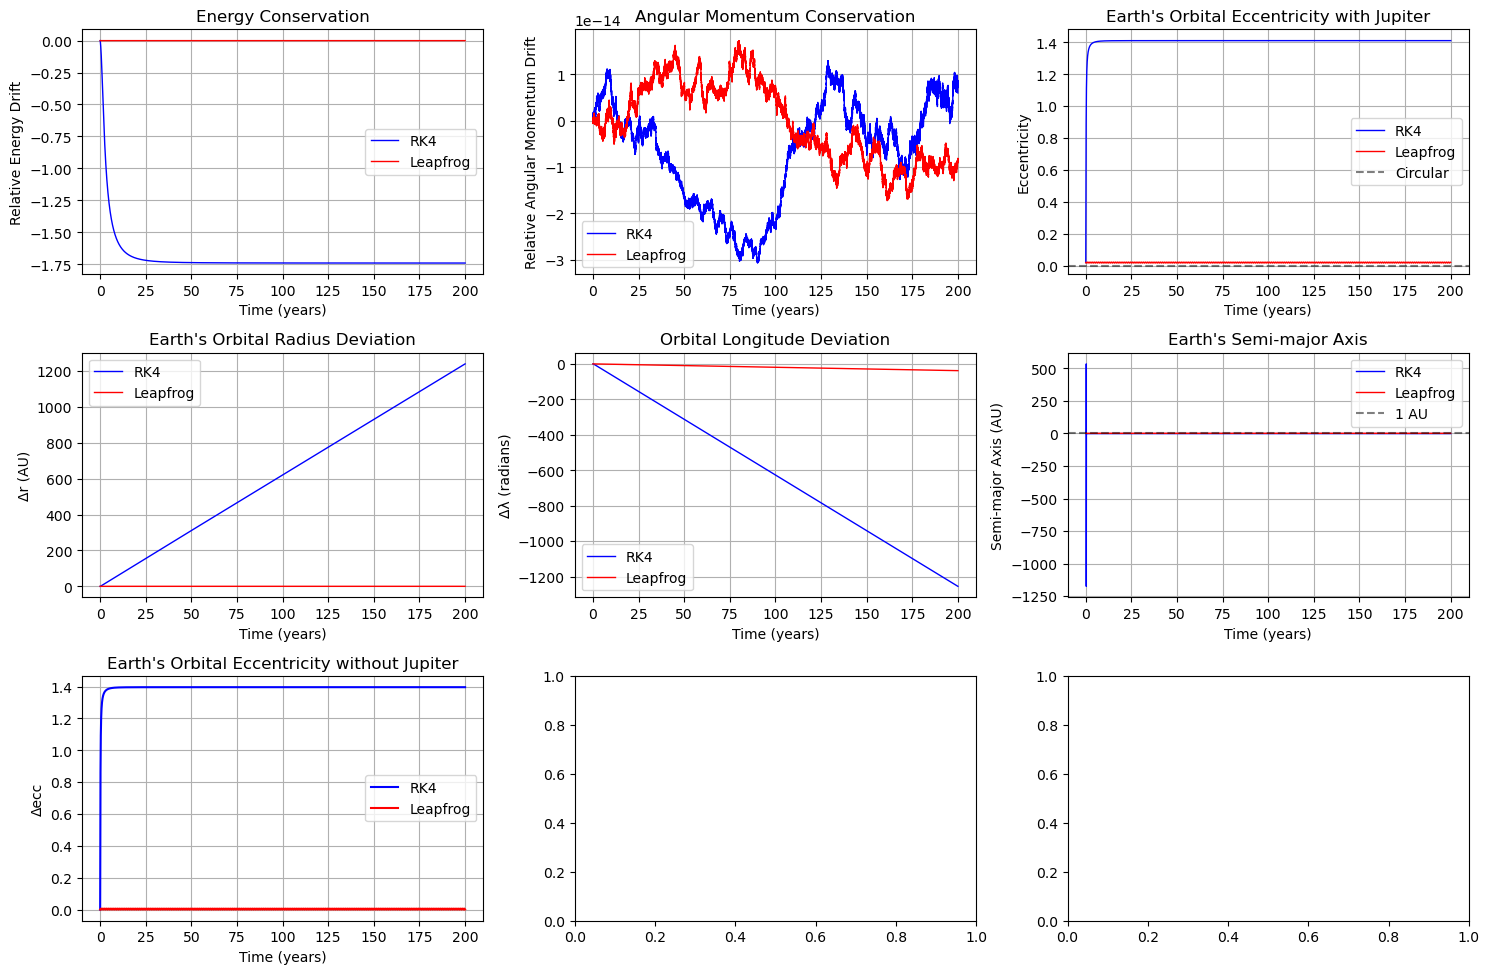


[3] Δecc Analysis:
RK4 Δecc range: 0.000000 to 1.390262
Leapfrog Δecc range: -0.002696 to 0.003472


In [13]:
if __name__ == "__main__":
    data = main()

In [ ]:
quantities = np.loadtxt("orbital_data.txt")

t_kyr = quantities[:, 0]
ecc = quantities[:, 1]
prec = quantities[:, 2]
obl= quantities[:, -1]

t_years = t_kyr*1000

In [ ]:
dt = 0.001
steps = int(t_years[-1] / dt)

pos_hist, vel_hist, _, _, _, _ = run_simulation(
    leapfrog_step, dt, steps, bodies='sun_earth', eccentric_init=False
)
r, lon = extract_earth_orbit(pos_hist, vel_hist, None)

from scipy.interpolate import interp1d

t_sim = np.arange(steps) * dt

f_r = interp1d(t_sim, r, fill_value="extrapolate")
f_lon = interp1d(t_sim, lon, fill_value="extrapolate")

r= f_r(time_years)
long = f_lon(time_years)

In [ ]:
#data used for calculation
combined = np.column_stack([
    t_years, # time
    ecc, # eccentricity 
    prec, # precession
    obl, # obliquity
    r, # calculated earth-sun distance
    long # calculated longtituide
])